In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import folium 

In [2]:
file_path = "/Learning/DI_Bootcamp/Week3/Day5/DailyChallenge/US Superstore data.xls"
df = pd.read_excel(file_path)

print(df.info())
print(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   object        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   object        
 5   Customer ID    9994 non-null   object        
 6   Customer Name  9994 non-null   object        
 7   Segment        9994 non-null   object        
 8   Country        9994 non-null   object        
 9   City           9994 non-null   object        
 10  State          9994 non-null   object        
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   object        
 13  Product ID     9994 non-null   object        
 14  Category       9994 non-null   object        
 15  Sub-Category   9994 n

In [3]:
columns_to_drop = ['Row ID', 'Postal Code']  
df = df.drop(columns=[col for col in columns_to_drop if col in df.columns], errors='ignore')

if 'Order Date' in df.columns:
    df['Order Date'] = pd.to_datetime(df['Order Date'])

if 'Ship Date' in df.columns:
    df['Ship Date'] = pd.to_datetime(df['Ship Date'])

if 'Order Date' in df.columns:
    df['Year'] = df['Order Date'].dt.year


print("\nMissing Values in Dataset:\n", df.isnull().sum())
print(df.head())



Missing Values in Dataset:
 Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Year             0
dtype: int64
         Order ID Order Date  Ship Date       Ship Mode Customer ID  \
0  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
1  CA-2016-152156 2016-11-08 2016-11-11    Second Class    CG-12520   
2  CA-2016-138688 2016-06-12 2016-06-16    Second Class    DV-13045   
3  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   
4  US-2015-108966 2015-10-11 2015-10-18  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky 

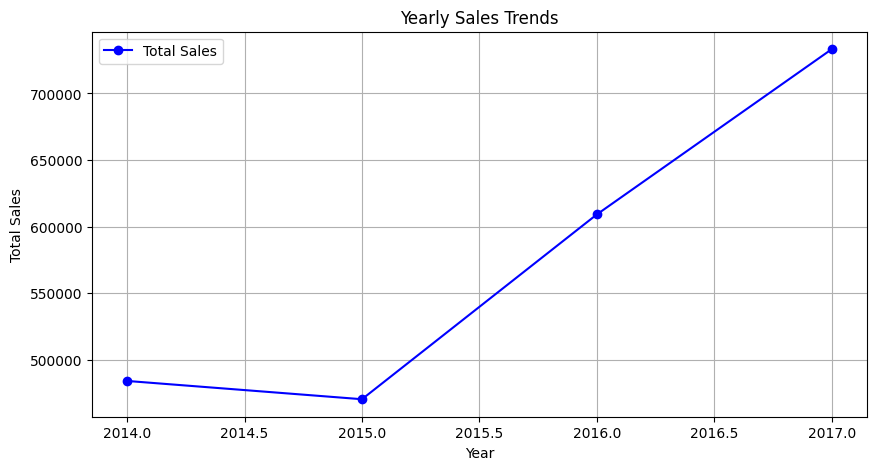

In [4]:
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(10, 5))
plt.plot(yearly_sales.index, yearly_sales.values, marker='o', linestyle='-', color='b', label='Total Sales')
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.title("Yearly Sales Trends")
plt.grid(True)
plt.legend()

plt.show()


In [7]:
state_sales = df.groupby('State')['Sales'].sum().reset_index()

m = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

state_coordinates = {
    "California": [36.7783, -119.4179],
    "New York": [40.7128, -74.0060],
    "Texas": [31.9686, -99.9018],
    "Florida": [27.9944024, -81.7602544],
}

for index, row in state_sales.iterrows():
    if row['State'] in state_coordinates:
        folium.Marker(
            location=state_coordinates[row['State']],
            popup=f"State: {row['State']}<br>Sales: ${row['Sales']:.2f}",
            icon=folium.Icon(color="purple")
        ).add_to(m)

m.save("sales_map.html")


C:\Users\Pinhas\AppData\Local\Temp\ipykernel_16856\4234485658.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sales', y='Product Name', data=top_products, palette='viridis')


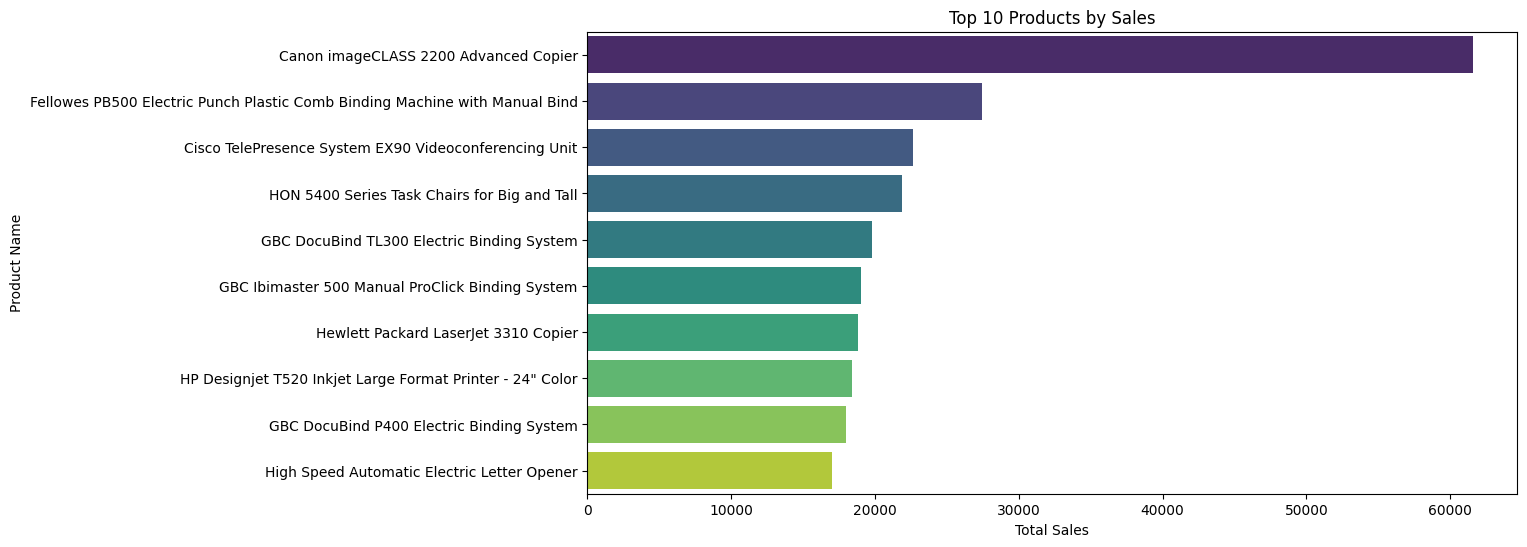

In [8]:
top_products = df.groupby('Product Name')['Sales'].sum().nlargest(10).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Sales', y='Product Name', data=top_products, palette='viridis')

plt.xlabel("Total Sales")
plt.ylabel("Product Name")
plt.title("Top 10 Products by Sales")

plt.show()


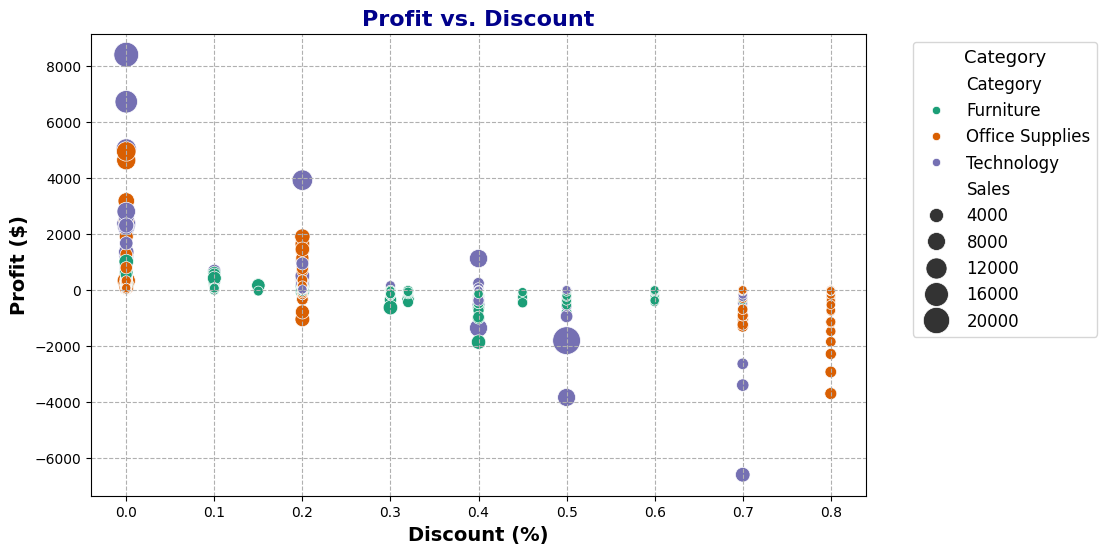

In [13]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=df['Discount'], 
    y=df['Profit'], 
    hue=df['Category'],
    size=df['Sales'],
    sizes=(40, 400), 
    alpha=1,
    palette="Dark2"
)

plt.xlabel("Discount (%)", fontsize=14, fontweight='bold')
plt.ylabel("Profit ($)", fontsize=14, fontweight='bold')
plt.title("Profit vs. Discount", fontsize=16, fontweight='bold', color="darkblue")
plt.legend(title="Category", fontsize=12, title_fontsize=13, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=1)

plt.show()


***Comparative Analysis: Matplotlib vs Seaborn***

Sales Trends (Matplotlib): Line chart
- It clearly shows overall sales trends over the years.
- Easy to interpret.
- Requires manual styling for better aesthetics.
- In my opinion seems to require more code.
- Matplotlib works well for **time-series analysis**.

Sales Distribution Map (I found Folium when I looked up for an interactive map):
- Great for visualizing **sales across different states**.
- Interactive and allows users to explore data dynamically and with a hands on feel.
- I found that Matplotlib/Seaborn did not work well for this task.
- **Folium is best for geospatial visualizations.**

Top 10 Products (Seaborn):
- Seems to have more styling options.
- Info is easy to read and understand.  
- Automatically applies great color schemes.
- Easier to generate compared to Matplotlib.
- Requires less code 
- **Seaborn is best for ranking and categorical comparisons.**

Profit vs Discount (Seaborn):
- Helps identify if discounts affect profits.
- Seaborn's built-in features make visualization easier.
- The legend was adjusted for clarity, proving Seaborn’s flexibility.



***In conclusion***
- **Matplotlib gives precise control but needs extra styling.**
- **Seaborn is much faster for making elegant charts.**
- **Folium is perfect for interactive geospatial maps.**
- **The best approach is to combine all three libraries!**